# Kinship Library
## Notebook 02: Process and Merge Collected Book Data

### Purpose
This notebook starts from the data already collected in Notebook 01 and the Google Books enrichment cache. It does not repeat API collection.

### Inputs
`data/processed/books_clean.csv`

`data/raw/google_books_enrichment.csv`

### Output
`data/processed/books_enriched.csv`

The output becomes the input for NLP, clustering and the recommender.

## 1. Setup

### Purpose
Mount Google Drive and define permanent project paths.

### Expected result
Both input CSV files should be found without rerunning collection.

In [1]:
from google.colab import drive
from pathlib import Path
from difflib import SequenceMatcher

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/kinship_library")
RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

CLEAN_FILE = PROCESSED_DATA / "books_clean.csv"
GOOGLE_CACHE_FILE = RAW_DATA / "google_books_enrichment.csv"
ENRICHED_FILE = PROCESSED_DATA / "books_enriched.csv"

print("Clean catalogue exists:", CLEAN_FILE.exists())
print("Google enrichment exists:", GOOGLE_CACHE_FILE.exists())

Mounted at /content/drive
Clean catalogue exists: True
Google enrichment exists: True


## 2. Load the collected data

### Purpose
Load the 925 cleaned Open Library books and every Google Books record that was saved before the kernel stopped.

In [2]:
books = pd.read_csv(CLEAN_FILE)
google_cache = pd.read_csv(GOOGLE_CACHE_FILE)

print("Clean Open Library books:", len(books))
print("Google enrichment records:", len(google_cache))

display(books.head())
display(google_cache.head())

Clean Open Library books: 925
Google enrichment records: 920


,source_id,title,author,description,subjects,published_year,average_rating,ratings_count,isbn,language,source,collection_theme,search_query,subject_count
0,/works/OL6772557W,The ecology of human development,Urie Bronfenbrenner,NaN,"Child psychology, Research, Human Development,...",1979.0,5.000000,1.0,9780674224575,eng,open_library,humans_and_nature,ecology human nature,5
1,/works/OL3458484W,People and nature,Emilio F. Moran,NaN,"Effect of environment on, Effect of environmen...",2006.0,NaN,NaN,1118877411,eng,open_library,humans_and_nature,ecology human nature,17
2,/works/OL2990533W,The green imperative,"Victor J. Papanek, Victor Papanek",NaN,"Design, industrial, Environmental aspects, Env...",1995.0,NaN,NaN,9780500296196,eng,open_library,humans_and_nature,ecology human nature,17
3,/works/OL1805267W,Design with nature,Ian L. McHarg,NaN,"Effect of environment on, Effect of human bein...",1969.0,4.333334,6.0,047111460X,eng,open_library,humans_and_nature,ecology human nature,17
4,/works/OL2911248W,"The death of nature: women, ecology, and the s...",Carolyn Merchant,NaN,"Human ecology, Philosophy of nature, Social as...",1980.0,NaN,NaN,9780062505712,eng,open_library,humans_and_nature,ecology human nature,15


,status,google_books_id,google_title,google_authors,description,categories,publisher,google_published_date,google_average_rating,google_ratings_count,source_id,open_library_title,open_library_author,isbn
0,found,OCmbzWka6xUC,The Ecology of Human Development,Urie Bronfenbrenner,"To understand the way children develop, Bronfe...",Family & Relationships,Harvard University Press,1979,3.5,3.0,/works/OL6772557W,The ecology of human development,Urie Bronfenbrenner,9780674224575
1,http_503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/works/OL3458484W,People and nature,Emilio F. Moran,1118877411
2,found,utWNEAAAQBAJ,The Green Imperative,"Victor Papanek, Thomas E. Lovejoy",A fresh edition of the sustainable design pion...,Architecture,National Geographic Books,2022-02-08,NaN,NaN,/works/OL2990533W,The green imperative,"Victor J. Papanek, Victor Papanek",9780500296196
3,found,b-cbngEACAAJ,Design with Nature,Ian L. McHarg,"This is a new paperback version of a text, ori...",Architecture,John Wiley & Sons,1969,NaN,NaN,/works/OL1805267W,Design with nature,Ian L. McHarg,047111460X
4,found,ot0pngEACAAJ,The death of nature,Carolyn Merchant,NaN,Philosophy of nature,NaN,1980,NaN,NaN,/works/OL2911248W,"The death of nature: women, ecology, and the s...",Carolyn Merchant,9780062505712


## 3. Inspect the Google enrichment cache

### Purpose
Understand what was actually collected before merging. A saved row is not automatically a successful match.

In [3]:
if "status" in google_cache.columns:
    display(
        google_cache["status"]
        .fillna("missing_status")
        .value_counts()
        .to_frame("count")
    )
else:
    print("No status column found. Successful matches will be inferred from google_books_id.")

successful_matches = (
    google_cache["google_books_id"].notna().sum()
    if "google_books_id" in google_cache.columns
    else 0
)

descriptions_found = (
    google_cache["description"].notna().sum()
    if "description" in google_cache.columns
    else 0
)

print("Successful Google matches:", successful_matches)
print("Descriptions found:", descriptions_found)

,count
status,
found,689
not_found,225
http_503,6


Successful Google matches: 689
Descriptions found: 477


## 4. Remove accidental duplicate enrichment rows

### Purpose
If a book was processed more than once, keep the row containing the most useful Google metadata.

In [4]:
google_cache["source_id"] = google_cache["source_id"].astype("string")

google_cache["has_google_description"] = (
    google_cache["description"].notna().astype(int)
    if "description" in google_cache.columns
    else 0
)

google_cache["has_google_match"] = (
    google_cache["google_books_id"].notna().astype(int)
    if "google_books_id" in google_cache.columns
    else 0
)

google_cache = (
    google_cache
    .sort_values(
        ["has_google_match", "has_google_description"],
        ascending=False
    )
    .drop_duplicates(subset="source_id", keep="first")
    .reset_index(drop=True)
)

print("Unique enrichment records:", len(google_cache))

Unique enrichment records: 920


## 5. Check Google title match quality

### Purpose
Google Books can return another edition of the same work. We calculate a simple title similarity score as quality control. This score is not part of the recommender.

In [5]:
def normalize_title(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def title_similarity(title_a, title_b):
    title_a = normalize_title(title_a)
    title_b = normalize_title(title_b)
    if title_a == "" or title_b == "":
        return np.nan
    return SequenceMatcher(None, title_a, title_b).ratio()

if "open_library_title" not in google_cache.columns:
    title_lookup = books[["source_id", "title"]].copy()
    title_lookup["source_id"] = title_lookup["source_id"].astype("string")
    title_lookup = title_lookup.rename(columns={"title":"open_library_title"})
    google_cache = google_cache.merge(title_lookup, on="source_id", how="left")

google_cache["title_similarity"] = google_cache.apply(
    lambda row: title_similarity(
        row.get("open_library_title"),
        row.get("google_title")
    ),
    axis=1
)

display(
    google_cache[
        ["open_library_title", "google_title", "google_authors", "title_similarity"]
    ]
    .sort_values("title_similarity")
    .head(20)
)

,open_library_title,google_title,google_authors,title_similarity
670,Nosotros los Wayuu,Literatura oral del Caribe colombiano,Jairo Mercado Romero,0.072727
609,Saminashi,Colombia años 50,Eduardo Sáenz Rovner,0.080000
506,Nasty Nature (Horrible Science),Protivná příroda,"Nick Arnold, Tony De Saulles, Michael Fokt",0.093023
534,The art of relaxation,Pranayama Yoga,Yogini Sunita,0.114286
567,Autobiography of a Yogi,La iluminada circunferencia,NaN,0.120000
633,Emberas territorio y biodiversidad : estrategi...,Emberás,"Camilo Antonio Hernández, María del Pilar Vale...",0.131868
665,U' sxakwe sa'tkwe ena's umnxi,Tejido de la vida de las mujeres y hombres nasa,Consejo Regional Indígena del Cauca,0.133333
612,Los muiscas,Historia de la jurisdicción eclesiástica de Tunja,Nepomuceno León Leal,0.133333
253,Ayurveda,"Ayurveda: Descubra Cual Es Su Constitucion, Co...",Robert Svoboda,0.135593
312,Neo-Tantra,The Return Journey,Frank Vilaasa,0.142857


## 6. Flag matches for review

### Purpose
Create a transparent quality rule.

A similarity of 0.80 or more is a strong title match. A similarity from 0.60 to 0.79 is a possible title match. Lower values are flagged for review.

This threshold is a practical project rule, not a universal statistical standard.

In [7]:
google_cache["match_quality"] = np.select(
    [
        google_cache["has_google_match"].eq(0),
        google_cache["title_similarity"].ge(0.80),
        google_cache["title_similarity"].ge(0.60)
    ],
    [
        "no_google_match",
        "strong_title_match",
        "possible_title_match"
    ],
    default="review"
)

display(
    google_cache["match_quality"]
    .value_counts()
    .to_frame("count")
)

review_matches = google_cache[
    google_cache["match_quality"].eq("review")
][
    ["open_library_title", "google_title", "google_authors", "description", "title_similarity","isbn"]
].copy()

print("Matches requiring review:", len(review_matches))
display(review_matches.head(30))

,count
match_quality,
strong_title_match,589
no_google_match,231
review,78
possible_title_match,22


Matches requiring review: 78


,open_library_title,google_title,google_authors,description,title_similarity,isbn
61,Ecofeminism,Ecofeminism: Feminist Intersections with Other...,"Carol J. Adams, Lori Gruen",This book first offers an historical overview ...,0.282051,1628928034
97,The good in nature and humanity : connecting s...,The Good in Nature and Humanity,"Stephen R. Kellert, Timothy Farnham","Scientists, theologians, and the spiritually i...",0.476923,NaN
105,Yogasūtra,The Yoga-Sutra of Patañjali,"Patañjali, Georg Feuerstein","The landmark scripture on classical yoga, thes...",0.444444,0892812621
110,Tree of Yoga,The Tree of Yoga: The Definitive Guide to Yoga...,B.K.S. Iyengar,The definitive guide to yoga in everyday life ...,0.324324,0007493282
120,Yogasūtra. English,The Yoga Sutras of Patanjali,"Patañjali, Charles Johnston",The Yoga Sutras were formulated in India in th...,0.533333,9780722401293
132,"Rig-veda, oder, Die heiligen lieder der Brahmanen","Rig-Veda-Sanhita, the sacred hymns of the Brah...","D 1387 Syaa, F Max (Friedrich Max) 1823-19 Müller",This work has been selected by scholars as bei...,0.290909,1016450516
152,The Bhagavad Gita,Īśvara-Arjuna saṃvāda,Yogananda (Paramahansa),"Commentary on Bhagavadgita, Hindu religious an...",0.222222,9789383203666
153,भगवद्गीता,The Bhagavad Gita,Eknath Easwaran,Easwaran is a leading authority on the Bhagava...,NaN,158638130X
166,Pantajali's Yoga Philosophy,Pantajali's,Dr Sriram Ananthan,Thepreciserootofyogaisstilamystery.Thereissome...,0.578947,9798689323831
177,Yoga Sastra : The Yoga Sutras of Patenjali Exa...,Yoga Sastra,"John Murdoch, Patanjali",This work has been selected by scholars as bei...,0.366667,0342835432


## 7. Select Google metadata for automatic use

### Purpose
Use descriptions automatically only for strong and possible title matches. Low similarity records remain in the data for inspection but do not contribute descriptions to NLP.

In [8]:
google_cache["use_google_metadata"] = (
    google_cache["match_quality"]
    .isin(["strong_title_match", "possible_title_match"])
)

print("Google records accepted:", int(google_cache["use_google_metadata"].sum()))

Google records accepted: 611


## 8. Prepare Google columns and merge

### Purpose
Preserve all 925 Open Library books. Google Books enriches them where a valid match exists.

In [10]:
google_for_merge = google_cache.copy()

google_for_merge = google_for_merge.rename(
    columns={
        "description": "google_description",
        "categories": "google_categories",
        "publisher": "google_publisher"
    }
)

columns_to_keep = [
    "source_id",
    "google_books_id",
    "google_title",
    "google_authors",
    "google_description",
    "google_categories",
    "google_publisher",
    "google_published_date",
    "google_average_rating",
    "google_ratings_count",
    "title_similarity",
    "match_quality",
    "use_google_metadata",
    "isbn"
]

columns_to_keep = [
    col for col in columns_to_keep
    if col in google_for_merge.columns
]

google_for_merge = google_for_merge[columns_to_keep].copy()

books["source_id"] = books["source_id"].astype("string")

books_enriched = books.merge(
    google_for_merge,
    on="source_id",
    how="left"
)

print("Books before merge:", len(books))
print("Books after merge:", len(books_enriched))

assert len(books_enriched) == len(books)

Books before merge: 925
Books after merge: 925


## 9. Create the final description

### Purpose
Use the Google description only when the match passed the quality rule. Books without a validated Google description remain in the catalogue.

In [11]:
if "google_description" not in books_enriched.columns:
    books_enriched["google_description"] = np.nan

if "use_google_metadata" not in books_enriched.columns:
    books_enriched["use_google_metadata"] = False

books_enriched["description_final"] = np.where(
    books_enriched["use_google_metadata"].fillna(False),
    books_enriched["google_description"],
    np.nan
)

print(
    "Final descriptions available:",
    books_enriched["description_final"].notna().sum()
)

print(
    "Final description coverage:",
    round(books_enriched["description_final"].notna().mean() * 100, 2),
    "%"
)

Final descriptions available: 432
Final description coverage: 46.7 %


/tmp/ipykernel_1594/3989779556.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  books_enriched["use_google_metadata"].fillna(False),


## 10. Measure enrichment improvement

### Purpose
Quantify the improvement in description availability. This is an important project result because the second API was introduced in response to missing data discovered during EDA.

,stage,description_coverage_percent
0,Open Library cleaned data,0.000000
1,After Google Books enrichment,46.702703


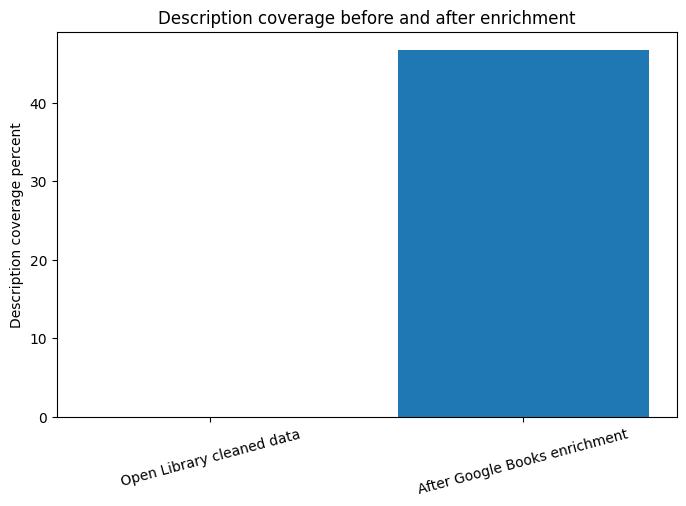

In [12]:
before_coverage = books["description"].notna().mean() * 100
after_coverage = books_enriched["description_final"].notna().mean() * 100

coverage_comparison = pd.DataFrame({
    "stage": [
        "Open Library cleaned data",
        "After Google Books enrichment"
    ],
    "description_coverage_percent": [
        before_coverage,
        after_coverage
    ]
})

display(coverage_comparison)

plt.figure(figsize=(8, 5))
plt.bar(
    coverage_comparison["stage"],
    coverage_comparison["description_coverage_percent"]
)
plt.title("Description coverage before and after enrichment")
plt.ylabel("Description coverage percent")
plt.xticks(rotation=15)
plt.show()

## 11. Missing values after enrichment

In [13]:
important_columns = [
    "title",
    "author",
    "subjects",
    "published_year",
    "average_rating",
    "ratings_count",
    "isbn",
    "language",
    "description_final",
    "google_categories"
]

important_columns = [
    col for col in important_columns
    if col in books_enriched.columns
]

missing_after = pd.DataFrame({
    "missing_count": books_enriched[important_columns].isna().sum(),
    "missing_percent": (
        books_enriched[important_columns].isna().mean() * 100
    ).round(2)
}).sort_values("missing_percent", ascending=False)

display(missing_after)

,missing_count,missing_percent
average_rating,812,87.78
ratings_count,812,87.78
description_final,493,53.30
google_categories,354,38.27
subjects,216,23.35
language,47,5.08
author,29,3.14
published_year,8,0.86
title,0,0.00


## 12. Create the final NLP text

### Purpose
Combine book metadata into one rich text field for TF IDF and semantic embeddings.

We intentionally keep `collection_theme` and `search_query` out of `semantic_text`. They describe how we found the book, not necessarily what the book itself means.

In [14]:
for col in [
    "title",
    "author",
    "subjects",
    "description_final",
    "google_categories"
]:
    if col not in books_enriched.columns:
        books_enriched[col] = ""

books_enriched["semantic_text"] = (
    books_enriched["title"].fillna("") + ". "
    + books_enriched["author"].fillna("") + ". "
    + books_enriched["subjects"].fillna("") + ". "
    + books_enriched["google_categories"].fillna("") + ". "
    + books_enriched["description_final"].fillna("")
)

books_enriched["semantic_text"] = (
    books_enriched["semantic_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

books_enriched["semantic_text_words"] = (
    books_enriched["semantic_text"]
    .str.split()
    .str.len()
)

display(
    books_enriched[
        ["title", "semantic_text_words", "semantic_text"]
    ].head()
)

,title,semantic_text_words,semantic_text
0,The ecology of human development,66,The ecology of human development. Urie Bronfen...
1,People and nature,49,People and nature. Emilio F. Moran. Effect of ...
2,The green imperative,240,"The green imperative. Victor J. Papanek, Victo..."
3,Design with nature,78,Design with nature. Ian L. McHarg. Effect of e...
4,"The death of nature: women, ecology, and the s...",55,"The death of nature: women, ecology, and the s..."


## 13. Check text richness and theme representation

### Purpose
Confirm that the final catalogue contains usable text and that all collection themes remain represented.

,value
count,925.000000
mean,78.605405
std,92.493962
min,4.000000
25%,15.000000
50%,35.000000
75%,123.000000
max,650.000000


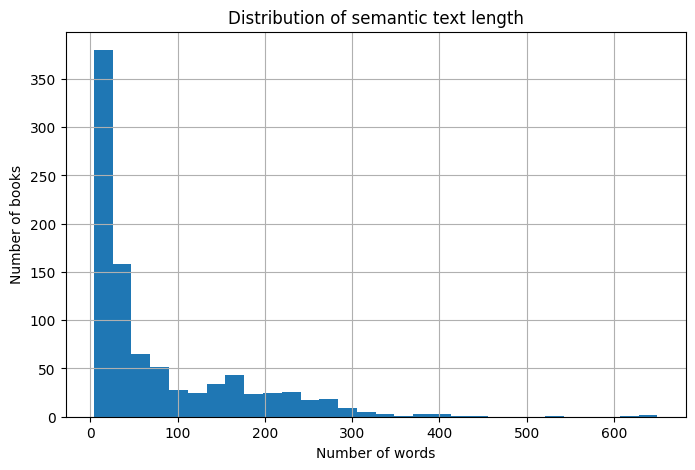

,books
collection_theme,
indigenous_knowledge_americas,368
humans_and_nature,176
yoga_philosophy,138
ayurveda_indian_spirituality,137
yoga_way_of_life,106


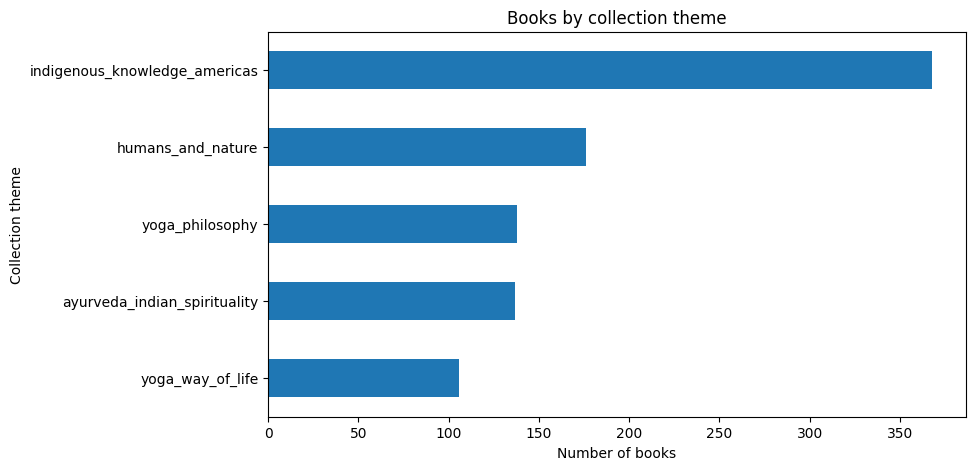

In [15]:
display(
    books_enriched["semantic_text_words"]
    .describe()
    .to_frame("value")
)

plt.figure(figsize=(8, 5))
books_enriched["semantic_text_words"].hist(bins=30)
plt.title("Distribution of semantic text length")
plt.xlabel("Number of words")
plt.ylabel("Number of books")
plt.show()

theme_counts = books_enriched["collection_theme"].value_counts()

display(theme_counts.to_frame("books"))

plt.figure(figsize=(9, 5))
theme_counts.sort_values().plot(kind="barh")
plt.title("Books by collection theme")
plt.xlabel("Number of books")
plt.ylabel("Collection theme")
plt.show()

In [16]:
books_enriched["nlp_text_quality"] = pd.cut(
    books_enriched["semantic_text_words"],
    bins=[
        -1,
        14,
        39,
        float("inf")
    ],
    labels=[
        "very_short",
        "limited",
        "rich"
    ]
)

display(
    books_enriched["nlp_text_quality"]
    .value_counts()
    .to_frame("books")
)

,books
nlp_text_quality,
rich,435
limited,278
very_short,212




*  very_short     0 to 14 words
*  limited       15 to 39 words
*  rich          40 words or more

In [17]:
pd.crosstab(
    books_enriched["collection_theme"],
    books_enriched["nlp_text_quality"]
)

nlp_text_quality,very_short,limited,rich
collection_theme,,,
ayurveda_indian_spirituality,57,28,52
humans_and_nature,27,43,106
indigenous_knowledge_americas,33,170,165
yoga_philosophy,52,21,65
yoga_way_of_life,43,16,47


## 14. Save the NLP ready catalogue

### Purpose
Create the permanent checkpoint for Notebook 03.

### Expected result
The saved file contains all clean books, validated Google metadata where available, and `semantic_text`.

In [18]:
books_enriched.to_csv(
    ENRICHED_FILE,
    index=False
)

print("Saved:", ENRICHED_FILE)
print("Rows:", len(books_enriched))
print("File exists:", ENRICHED_FILE.exists())

Saved: /content/drive/MyDrive/kinship_library/data/processed/books_enriched.csv
Rows: 925
File exists: True


## 15. Final checkpoint

Keep this output for the project presentation. It summarizes the transition from collection to NLP ready data.

In [19]:
print("KINSHIP LIBRARY DATA CHECKPOINT")
print()

print("Clean Open Library books:", len(books))
print("Google enrichment records:", len(google_cache))
print(
    "Accepted Google matches:",
    int(google_cache["use_google_metadata"].sum())
)
print(
    "Descriptions available:",
    books_enriched["description_final"].notna().sum()
)
print(
    "Description coverage:",
    round(
        books_enriched["description_final"].notna().mean() * 100,
        2
    ),
    "%"
)
print("Final NLP ready books:", len(books_enriched))

KINSHIP LIBRARY DATA CHECKPOINT

Clean Open Library books: 925
Google enrichment records: 920
Accepted Google matches: 611
Descriptions available: 432
Description coverage: 46.7 %
Final NLP ready books: 925


Flow:
925 collected books → metadata enrichment → text quality assessment → NLP
eligible catalogue → embeddings → K Means and PCA → semantic recommender.